## НИР. 2 семестр
# Метод распознавания составных эмоций по мимике лица на основе базовых эмоциональных состояний
## Гусева Надежда Леонидовна, М4121

## 1. Педварительная обработка изображений лица

In [ ]:
pip install mtcnn ultralytics

In [ ]:
import cv2
import numpy as np
from mtcnn.mtcnn import MTCNN
from PIL import Image
import os
import matplotlib.pyplot as plt
from ultralytics import YOLO

Matplotlib is building the font cache; this may take a moment.


In [ ]:
# Путь к модели YOLOv8
YOLO_MODEL_PATH = "/home/guseva-n@ad.speechpro.com/dsp/НИР/2 семестр/Датасеты/yolov8n-face.pt"

In [ ]:
# Локализация и выравнивание лица
# target_size — размер, до которого будет масштабировано лицо (224x224 — стандартный размер для CNN, например, ResNet)
def detect_and_align_face(image_path, target_size=(224, 224)): 
    
    yolo_model = YOLO(YOLO_MODEL_PATH)
    
    # Загрузка изображения
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # OpenCV -> RGB

    result = yolo_model.predict(image_path, conf=0.5)

    if not result:
        raise ValueError(f"Не найдено лицо в изображении: {image_path}")

    # Берём первое обнаруженное лицо
    bounding_box = result[0]['box']
    landmarks = result[0]['keypoints']

    # Обрезка лица
    x, y, width, height = bounding_box
    face = image[y:y+height, x:x+width]

    # Выравнивание по глазам
    # Поворачиваем лицо так, чтобы глаза были горизонтальными
    # Получение координат глаз
    left_eye = [int(x) for x in landmarks['left_eye']]
    right_eye = [int(x) for x in landmarks['right_eye']]

    # Вычисление угла поворота
    dy = right_eye[1] - left_eye[1]
    dx = right_eye[0] - left_eye[0]
    angle = np.degrees(np.arctan2(dy, dx))

    # Центр поворота — середина между глазами
    cx = (left_eye[0] + right_eye[0]) // 2
    cy = (left_eye[1] + right_eye[1]) // 2
    
    # Матрица поворота
    M = cv2.getRotationMatrix2D((cx, cy), angle, scale=1.0)
    aligned_face = cv2.warpAffine(face, M, (face.shape[1], face.shape[0]))

    # Масштабирование
    # Уменьшаем или увеличиваем лицо до нужного размера (например, 224x224)
    aligned_face = cv2.resize(aligned_face, target_size)

    # Нормализация значений пикселей
    # Значения пикселей из 0–255 приводятся к 0.0–1.0
    # Это нужно для нормализации перед подачей в нейросеть
    aligned_face = aligned_face.astype('float32') / 255.0

    return aligned_face

# Применяет функцию detect_and_align_face
# Сохраняет обработанное лицо в указанную папку
def process_image(image_path, output_dir):
    try:
        processed_face = detect_and_align_face(image_path)
        # Сохранение изображения
        filename = os.path.basename(image_path)
        output_path = os.path.join(output_dir, filename)
        cv2.imwrite(output_path, (processed_face * 255).astype(np.uint8))
        print(f"✅ Обработано и сохранено: {output_path}")
    except Exception as e:
        print(f"❌ Ошибка при обработке {image_path}: {e}")

# Обработка всех изображений в папке
def process_folder(input_dir, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for filename in os.listdir(input_dir):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_path = os.path.join(input_dir, filename)
            process_image(image_path, output_dir)


In [8]:
# Выводит исходное и обработанное изображение на экран
def visualize(image_path):
    original = cv2.imread(image_path)
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    processed = detect_and_align_face(image_path)

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(original)
    ax[0].set_title("Исходное изображение")
    ax[1].imshow(processed)
    ax[1].set_title("Обработанное изображение")
    plt.show()

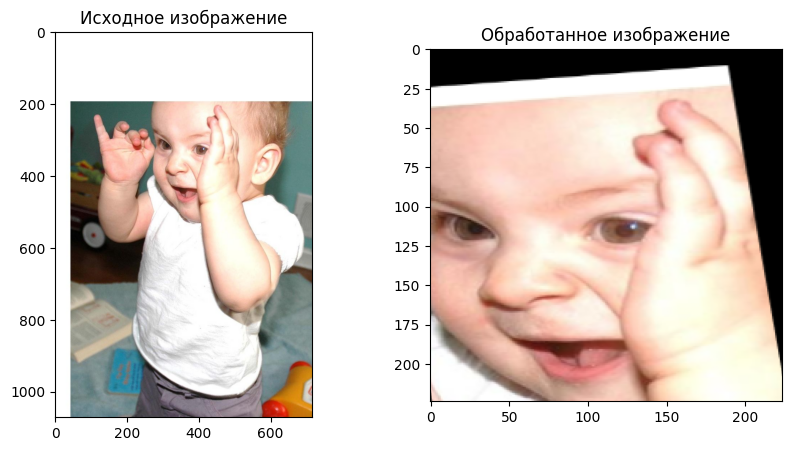

In [11]:
visualize("/home/guseva-n@ad.speechpro.com/dsp/НИР/2 семестр/Фото для предобработки/test_001.jpg")

In [12]:
# Указываем пути к исходным и выходным папкам
# Запускаем обработку всех изображений
if __name__ == "__main__":
    input_folder = "/home/guseva-n@ad.speechpro.com/dsp/НИР/2 семестр/Фото для предобработки"  # папка с исходными изображениями
    output_folder = "/home/guseva-n@ad.speechpro.com/dsp/НИР/2 семестр/Фото предобработанные"  # папка для обработанных изображений

    process_folder(input_folder, output_folder)

✅ Обработано и сохранено: /home/guseva-n@ad.speechpro.com/dsp/НИР/2 семестр/Фото предобработанные/test_010.jpg
✅ Обработано и сохранено: /home/guseva-n@ad.speechpro.com/dsp/НИР/2 семестр/Фото предобработанные/test_006.jpg
✅ Обработано и сохранено: /home/guseva-n@ad.speechpro.com/dsp/НИР/2 семестр/Фото предобработанные/test_003.jpg
❌ Ошибка при обработке /home/guseva-n@ad.speechpro.com/dsp/НИР/2 семестр/Фото для предобработки/test_018.jpg: Не найдено лицо в изображении: /home/guseva-n@ad.speechpro.com/dsp/НИР/2 семестр/Фото для предобработки/test_018.jpg
✅ Обработано и сохранено: /home/guseva-n@ad.speechpro.com/dsp/НИР/2 семестр/Фото предобработанные/test_013.jpg
✅ Обработано и сохранено: /home/guseva-n@ad.speechpro.com/dsp/НИР/2 семестр/Фото предобработанные/test_020.jpg
✅ Обработано и сохранено: /home/guseva-n@ad.speechpro.com/dsp/НИР/2 семестр/Фото предобработанные/test_002.jpg
✅ Обработано и сохранено: /home/guseva-n@ad.speechpro.com/dsp/НИР/2 семестр/Фото предобработанные/test_001.